In [1]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, roc_auc_score, 
                             confusion_matrix, roc_curve, f1_score,
                             precision_recall_curve, average_precision_score,
                             balanced_accuracy_score, recall_score, precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTENC, SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTEENN
import joblib
import warnings
warnings.filterwarnings('ignore')

# Configuration
np.random.seed(42)

In [4]:

# 2. CHARGEMENT DES DONNÉES


df = pd.read_csv("neonatal_mortality_data.csv", sep = ';')


print("DONNÉES EDS CAMEROUN 2018 - MORTALITÉ NÉONATALE")

print(f"\nDimensions : {df.shape}")
print(f"\nDistribution AVANT SMOTE:")
print(df['neonatal_mort'].value_counts())
print(f"\nTaux mortalité : {df['neonatal_mort'].mean():.2%}")

DONNÉES EDS CAMEROUN 2018 - MORTALITÉ NÉONATALE

Dimensions : (33988, 15)

Distribution AVANT SMOTE:
neonatal_mort
0    32891
1     1097
Name: count, dtype: int64

Taux mortalité : 3.23%


In [5]:

# 3. PRÉPARATION


# Variables disponibles (adapter selon votre export R)
features = ['maternal_age', 'maternal_age_sq', 'parity', 'sex_child',
            'education', 'wealth', 'residence', 'region', 
            'baby_size', 'birth_interval', 'anc_visits']

# Garder uniquement les variables présentes
features = [f for f in features if f in df.columns]
target = 'neonatal_mort'

X = df[features].copy()
y = df[target].copy()

# Split stratifié (CRUCIAL pour données déséquilibrées)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {X_train.shape[0]}, Test : {X_test.shape[0]}")
print(f"Taux mortalité - Train : {y_train.mean():.2%}, Test : {y_test.mean():.2%}")


Train : 27190, Test : 6798
Taux mortalité - Train : 3.23%, Test : 3.22%


In [6]:

# 4. IDENTIFICATION DES VARIABLES


numeric_features = [f for f in ['maternal_age', 'maternal_age_sq', 'parity'] 
                    if f in features]
categorical_features = [f for f in features if f not in numeric_features]

# Indices des variables catégorielles pour SMOTENC
cat_indices = [X.columns.get_loc(col) for col in categorical_features]

print(f"\nVariables numériques : {numeric_features}")
print(f"Variables catégorielles : {categorical_features}")
print(f"Indices catégoriels pour SMOTENC : {cat_indices}")


Variables numériques : ['maternal_age', 'maternal_age_sq', 'parity']
Variables catégorielles : ['sex_child', 'education', 'wealth', 'residence', 'region', 'baby_size', 'birth_interval', 'anc_visits']
Indices catégoriels pour SMOTENC : [3, 4, 5, 6, 7, 8, 9, 10]


In [7]:

# 5. PRÉTRAITEMENT SANS SMOTE (baseline)


preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])


In [8]:

# 6. PRÉTRAITEMENT AVEC SMOTE


def create_smote_pipeline(model, use_smote=True):
    """
    Crée un pipeline avec ou sans SMOTE

    Pour SMOTE sur données mixtes (numériques + catégorielles),
    on utilise SMOTENC qui gère les variables catégorielles.
    Alternative : encoder d'abord, puis appliquer SMOTE classique.
    """
    if use_smote:
        # Approche 1 : Encoder d'abord, puis SMOTE (plus simple)
        # On crée un pipeline imbriqué
        return ImbPipeline([
            ('preprocessor', preprocessor),
            ('smote', SMOTE(random_state=42, k_neighbors=5)),
            ('classifier', model)
        ])
    else:
        return Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])


In [9]:

# 7. MODÈLES À COMPARER (avec et sans SMOTE)


models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_split=10,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        scale_pos_weight=10, random_state=42,
        use_label_encoder=False, eval_metric='logloss'
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        class_weight='balanced', random_state=42, verbose=-1
    )
}


In [10]:

# 8. FONCTION D'ÉVALUATION COMPLÈTE


def evaluate_model(name, model, X_test, y_test, use_smote=False):
    """Évalue un modèle et retourne toutes les métriques"""

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Métriques
    auc = roc_auc_score(y_test, y_prob)
    f1 = f1_score(y_test, y_pred)
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    avg_precision = average_precision_score(y_test, y_prob)

    print(f"\n{'-'*50}")
    print(f"Modèle : {name} {'(avec SMOTE)' if use_smote else '(sans SMOTE)'}")
    print(f"{'-'*50}")
    print(f"AUC-ROC          : {auc:.4f}")
    print(f"F1-Score         : {f1:.4f}")
    print(f"F1-Score (pondéré): {f1_weighted:.4f}")
    print(f"Balanced Accuracy : {balanced_acc:.4f}")
    print(f"Recall (Sensibilité): {recall:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Average Precision : {avg_precision:.4f}")
    print(f"\nMatrice de confusion:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, 
                               target_names=['Survie', 'Décès'], 
                               digits=3))

    return {
        'name': name,
        'smote': use_smote,
        'auc': auc,
        'f1': f1,
        'f1_weighted': f1_weighted,
        'balanced_acc': balanced_acc,
        'recall': recall,
        'precision': precision,
        'avg_precision': avg_precision,
        'y_prob': y_prob,
        'y_pred': y_pred,
        'model': model
    }

In [11]:

# 9. ENTRAÎNEMENT ET ÉVALUATION - SANS SMOTE


results_no_smote = []

print("\n" + "="*60)
print("ENTRAÎNEMENT SANS SMOTE (BASELINE)")


for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Entraînement : {name}")
    print(f"{'='*50}")

    pipeline = create_smote_pipeline(model, use_smote=False)
    pipeline.fit(X_train, y_train)

    result = evaluate_model(name, pipeline, X_test, y_test, use_smote=False)
    results_no_smote.append(result)



ENTRAÎNEMENT SANS SMOTE (BASELINE)

Entraînement : Logistic Regression

--------------------------------------------------
Modèle : Logistic Regression (sans SMOTE)
--------------------------------------------------
AUC-ROC          : 0.6842
F1-Score         : 0.1057
F1-Score (pondéré): 0.7580
Balanced Accuracy : 0.6474
Recall (Sensibilité): 0.6484
Precision         : 0.0575
Average Precision : 0.0969

Matrice de confusion:
[[4253 2326]
 [  77  142]]

Classification Report:
              precision    recall  f1-score   support

      Survie      0.982     0.646     0.780      6579
       Décès      0.058     0.648     0.106       219

    accuracy                          0.647      6798
   macro avg      0.520     0.647     0.443      6798
weighted avg      0.952     0.647     0.758      6798


Entraînement : Random Forest

--------------------------------------------------
Modèle : Random Forest (sans SMOTE)
--------------------------------------------------
AUC-ROC          : 0.659

In [12]:

# 10. ENTRAÎNEMENT ET ÉVALUATION - AVEC SMOTE


results_smote = []

print("\n" + "="*60)
print("ENTRAÎNEMENT AVEC SMOTE (SUR-ÉCHANTILLONNAGE)")

print("SMOTE génère des exemples synthétiques de la classe minoritaire")
print("pour équilibrer le jeu d'entraînement.\n")

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Entraînement : {name} + SMOTE")
    print(f"{'='*50}")

    pipeline = create_smote_pipeline(model, use_smote=True)
    pipeline.fit(X_train, y_train)

    result = evaluate_model(name, pipeline, X_test, y_test, use_smote=True)
    results_smote.append(result)



ENTRAÎNEMENT AVEC SMOTE (SUR-ÉCHANTILLONNAGE)
SMOTE génère des exemples synthétiques de la classe minoritaire
pour équilibrer le jeu d'entraînement.


Entraînement : Logistic Regression + SMOTE

--------------------------------------------------
Modèle : Logistic Regression (avec SMOTE)
--------------------------------------------------
AUC-ROC          : 0.6863
F1-Score         : 0.1020
F1-Score (pondéré): 0.7453
Balanced Accuracy : 0.6409
Recall (Sensibilité): 0.6530
Precision         : 0.0553
Average Precision : 0.1008

Matrice de confusion:
[[4137 2442]
 [  76  143]]

Classification Report:
              precision    recall  f1-score   support

      Survie      0.982     0.629     0.767      6579
       Décès      0.055     0.653     0.102       219

    accuracy                          0.630      6798
   macro avg      0.519     0.641     0.434      6798
weighted avg      0.952     0.630     0.745      6798


Entraînement : Random Forest + SMOTE

-------------------------------

In [13]:

# 11. COMPARAISON SMOTE vs NON-SMOTE


print("\n" + "="*60)
print("COMPARAISON SMOTE vs NON-SMOTE")


comparison_df = pd.DataFrame()

for r_no, r_smote in zip(results_no_smote, results_smote):
    row = {
        'Modèle': r_no['name'],
        'AUC (sans SMOTE)': r_no['auc'],
        'AUC (avec SMOTE)': r_smote['auc'],
        'F1 (sans SMOTE)': r_no['f1'],
        'F1 (avec SMOTE)': r_smote['f1'],
        'Recall (sans SMOTE)': r_no['recall'],
        'Recall (avec SMOTE)': r_smote['recall'],
        'Balanced Acc (sans)': r_no['balanced_acc'],
        'Balanced Acc (avec)': r_smote['balanced_acc'],
        'Δ AUC': r_smote['auc'] - r_no['auc'],
        'Δ F1': r_smote['f1'] - r_no['f1'],
        'Δ Recall': r_smote['recall'] - r_no['recall']
    }
    comparison_df = pd.concat([comparison_df, pd.DataFrame([row])], ignore_index=True)

print(comparison_df.to_string(index=False))


COMPARAISON SMOTE vs NON-SMOTE
             Modèle  AUC (sans SMOTE)  AUC (avec SMOTE)  F1 (sans SMOTE)  F1 (avec SMOTE)  Recall (sans SMOTE)  Recall (avec SMOTE)  Balanced Acc (sans)  Balanced Acc (avec)     Δ AUC      Δ F1  Δ Recall
Logistic Regression          0.684169          0.686303         0.105694         0.101997             0.648402             0.652968             0.647426             0.640894  0.002134 -0.003697  0.004566
      Random Forest          0.659666          0.649167         0.125322         0.114943             0.333333             0.251142             0.600319             0.573663 -0.010498 -0.010379 -0.082192
  Gradient Boosting          0.693426          0.665596         0.016667         0.102941             0.009132             0.063927             0.503122             0.528999 -0.027830  0.086275  0.054795
            XGBoost          0.695204          0.666058         0.167033         0.117801             0.173516             0.410959             0.571710

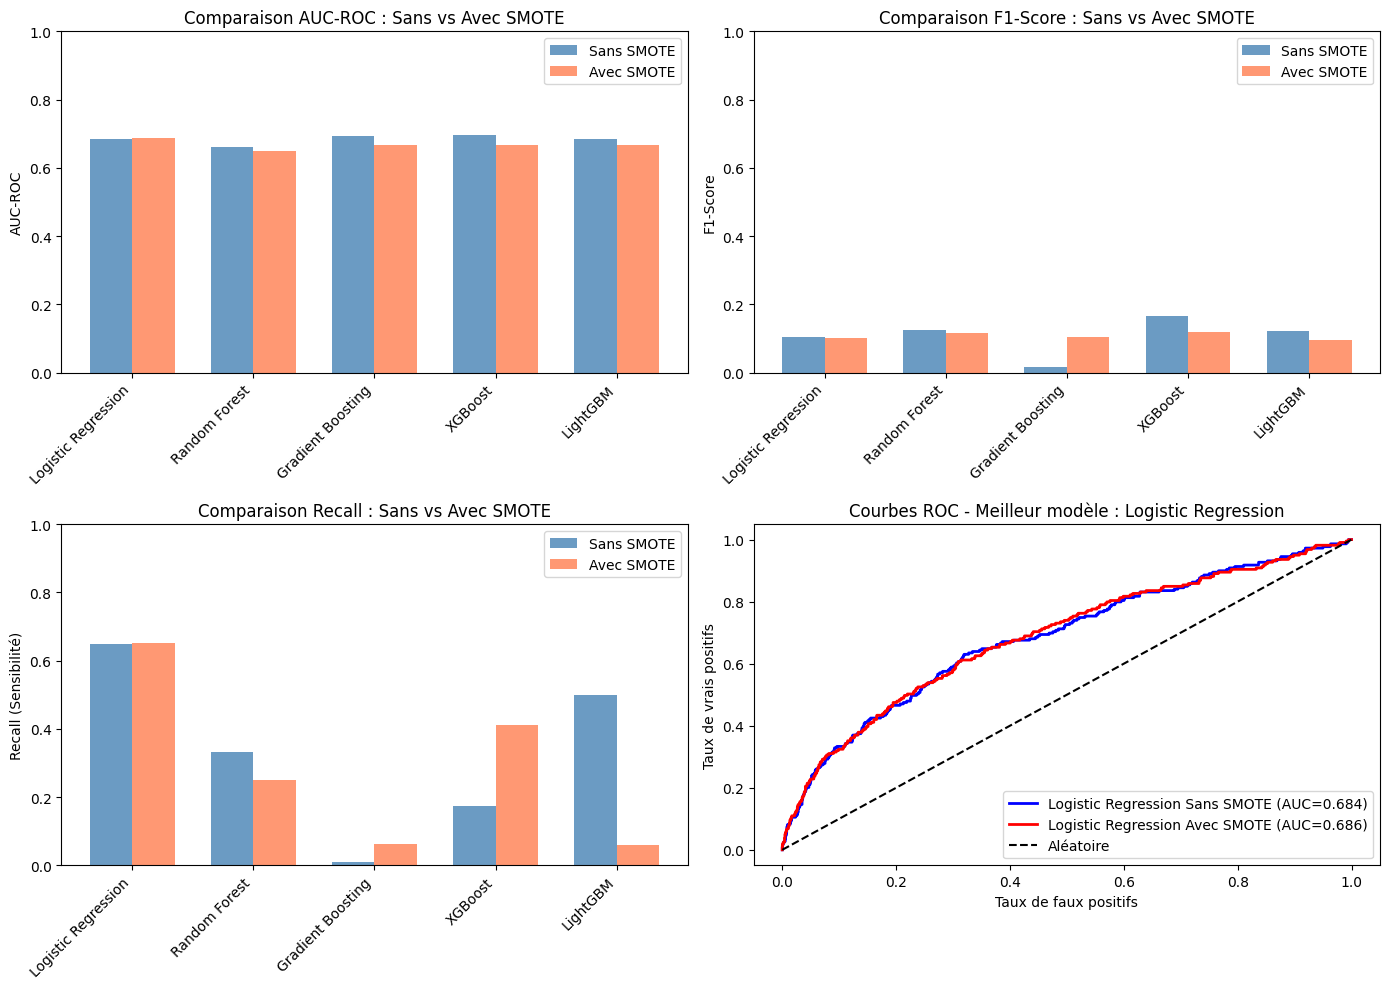

In [14]:

# 12. VISUALISATION COMPARATIVE


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Comparaison AUC-ROC
x = np.arange(len(comparison_df))
width = 0.35
axes[0,0].bar(x - width/2, comparison_df['AUC (sans SMOTE)'], width, 
              label='Sans SMOTE', alpha=0.8, color='steelblue')
axes[0,0].bar(x + width/2, comparison_df['AUC (avec SMOTE)'], width,
              label='Avec SMOTE', alpha=0.8, color='coral')
axes[0,0].set_ylabel('AUC-ROC')
axes[0,0].set_title('Comparaison AUC-ROC : Sans vs Avec SMOTE')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(comparison_df['Modèle'], rotation=45, ha='right')
axes[0,0].legend()
axes[0,0].set_ylim(0, 1)

# 2. Comparaison F1-Score
axes[0,1].bar(x - width/2, comparison_df['F1 (sans SMOTE)'], width,
              label='Sans SMOTE', alpha=0.8, color='steelblue')
axes[0,1].bar(x + width/2, comparison_df['F1 (avec SMOTE)'], width,
              label='Avec SMOTE', alpha=0.8, color='coral')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].set_title('Comparaison F1-Score : Sans vs Avec SMOTE')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(comparison_df['Modèle'], rotation=45, ha='right')
axes[0,1].legend()
axes[0,1].set_ylim(0, 1)

# 3. Comparaison Recall (Sensibilité)
axes[1,0].bar(x - width/2, comparison_df['Recall (sans SMOTE)'], width,
              label='Sans SMOTE', alpha=0.8, color='steelblue')
axes[1,0].bar(x + width/2, comparison_df['Recall (avec SMOTE)'], width,
              label='Avec SMOTE', alpha=0.8, color='coral')
axes[1,0].set_ylabel('Recall (Sensibilité)')
axes[1,0].set_title('Comparaison Recall : Sans vs Avec SMOTE')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(comparison_df['Modèle'], rotation=45, ha='right')
axes[1,0].legend()
axes[1,0].set_ylim(0, 1)

# 4. Courbes ROC comparées (meilleur modèle)
best_idx = comparison_df['AUC (avec SMOTE)'].idxmax()
best_name = comparison_df.loc[best_idx, 'Modèle']

for result_set, label, color in [(results_no_smote, 'Sans SMOTE', 'blue'),
                                  (results_smote, 'Avec SMOTE', 'red')]:
    for r in result_set:
        if r['name'] == best_name:
            fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
            axes[1,1].plot(fpr, tpr, label=f"{r['name']} {label} (AUC={r['auc']:.3f})", 
                          color=color, linewidth=2)

axes[1,1].plot([0, 1], [0, 1], 'k--', label='Aléatoire')
axes[1,1].set_xlabel('Taux de faux positifs')
axes[1,1].set_ylabel('Taux de vrais positifs')
axes[1,1].set_title(f'Courbes ROC - Meilleur modèle : {best_name}')
axes[1,1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('comparaison_smote.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:

# 13. MEILLEUR MODÈLE FINAL (avec SMOTE)


best_smote = max(results_smote, key=lambda x: x['auc'])

print(f"MEILLEUR MODÈLE AVEC SMOTE : {best_smote['name']}")
print(f"{'='*60}")
print(f"AUC-ROC : {best_smote['auc']:.4f}")
print(f"F1-Score : {best_smote['f1']:.4f}")
print(f"Recall : {best_smote['recall']:.4f}")
print(f"Balanced Accuracy : {best_smote['balanced_acc']:.4f}")


MEILLEUR MODÈLE AVEC SMOTE : Logistic Regression
AUC-ROC : 0.6863
F1-Score : 0.1020
Recall : 0.6530
Balanced Accuracy : 0.6409


In [16]:

# 14. IMPORTANCE DES VARIABLES (modèle SMOTE)


if best_smote['name'] in ['Random Forest', 'XGBoost', 'LightGBM']:
    best_model = best_smote['model'].named_steps['classifier']
    preprocessor_fitted = best_smote['model'].named_steps['preprocessor']

    feature_names = (numeric_features + 
                    list(preprocessor_fitted.named_transformers_['cat']
                        .named_steps['onehot']
                        .get_feature_names_out(categorical_features)))

    importance_df = pd.DataFrame({
        'Variable': feature_names,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    print(f"\nTop 15 variables les plus importantes (SMOTE) :")
    print(importance_df.to_string(index=False))

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Variable'][::-1], importance_df['Importance'][::-1])
    plt.xlabel('Importance')
    plt.title(f'Importance des variables - {best_smote["name"]} (avec SMOTE)')
    plt.tight_layout()
    plt.savefig('importance_variables_smote.png', dpi=300)
    plt.show()

In [17]:

# 15. SMOTEENN (Alternative : SMOTE + Edited Nearest Neighbours)

print("TEST AVEC SMOTEENN (SMOTE + Nettoyage)")


# SMOTEENN combine sur-échantillonnage SMOTE et sous-échantillonnage ENN
pipeline_smoteenn = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=42, use_label_encoder=False, eval_metric='logloss'
    ))
])

pipeline_smoteenn.fit(X_train, y_train)
result_smoteenn = evaluate_model("XGBoost + SMOTEENN", pipeline_smoteenn, X_test, y_test)

TEST AVEC SMOTEENN (SMOTE + Nettoyage)

--------------------------------------------------
Modèle : XGBoost + SMOTEENN (sans SMOTE)
--------------------------------------------------
AUC-ROC          : 0.6778
F1-Score         : 0.1126
F1-Score (pondéré): 0.9519
Balanced Accuracy : 0.5338
Recall (Sensibilité): 0.0776
Precision         : 0.2048
Average Precision : 0.0970

Matrice de confusion:
[[6513   66]
 [ 202   17]]

Classification Report:
              precision    recall  f1-score   support

      Survie      0.970     0.990     0.980      6579
       Décès      0.205     0.078     0.113       219

    accuracy                          0.961      6798
   macro avg      0.587     0.534     0.546      6798
weighted avg      0.945     0.961     0.952      6798



In [18]:

# 16. SAUVEGARDE DES MODÈLES


# Sauvegarder le meilleur modèle SMOTE
joblib.dump(best_smote['model'], 'best_neonatal_model_smote.pkl')
print(f"\n✅ Modèle SMOTE sauvegardé : best_neonatal_model_smote.pkl")

# Sauvegarder le modèle sans SMOTE pour comparaison
best_no_smote = max(results_no_smote, key=lambda x: x['auc'])
joblib.dump(best_no_smote['model'], 'best_neonatal_model_no_smote.pkl')
print(f"✅ Modèle sans SMOTE sauvegardé : best_neonatal_model_no_smote.pkl")

# Sauvegarder les résultats
results_df = pd.concat([
    pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_prob', 'y_pred', 'model']} 
                  for r in results_no_smote]),
    pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_prob', 'y_pred', 'model']} 
                  for r in results_smote])
])
results_df.to_csv('results_comparison_smote.csv', index=False)
print(f"✅ Résultats sauvegardés : results_comparison_smote.csv")


print("RÉSUMÉ FINAL")

print(f"Meilleur modèle SANS SMOTE : {best_no_smote['name']} (AUC={best_no_smote['auc']:.3f})")
print(f"Meilleur modèle AVEC SMOTE : {best_smote['name']} (AUC={best_smote['auc']:.3f})")
print(f"Meilleur modèle SMOTEENN   : XGBoost + SMOTEENN (AUC={result_smoteenn['auc']:.3f})")
print(f"\nAmélioration F1 avec SMOTE : {best_smote['f1'] - best_no_smote['f1']:+.3f}")
print(f"Amélioration Recall avec SMOTE : {best_smote['recall'] - best_no_smote['recall']:+.3f}")



✅ Modèle SMOTE sauvegardé : best_neonatal_model_smote.pkl
✅ Modèle sans SMOTE sauvegardé : best_neonatal_model_no_smote.pkl
✅ Résultats sauvegardés : results_comparison_smote.csv
RÉSUMÉ FINAL
Meilleur modèle SANS SMOTE : XGBoost (AUC=0.695)
Meilleur modèle AVEC SMOTE : Logistic Regression (AUC=0.686)
Meilleur modèle SMOTEENN   : XGBoost + SMOTEENN (AUC=0.678)

Amélioration F1 avec SMOTE : -0.065
Amélioration Recall avec SMOTE : +0.479
